In [1]:
# Install Ultralytics (YOLOv8 library)
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


## STEP 1: Upload Your Dataset
Run the cell below to open an interactive upload button. Click it and select your `grocery.v1i.yolov8.zip` file to securely upload it directly to Colab's temporary memory.

In [2]:
from google.colab import files

print("Please click the 'Choose Files' button and upload 'grocery.v1i.yolov8.zip':")
uploaded = files.upload()

for file_name in uploaded.keys():
    print(f"\nSuccessfully uploaded {file_name}!")


Please click the 'Choose Files' button and upload 'grocery.v1i.yolov8.zip':


Saving grocery.v1i.yolov8.zip to grocery.v1i.yolov8.zip

Successfully uploaded grocery.v1i.yolov8.zip!


## STEP 2: Unzip Your Dataset
Manually upload your dataset `.zip` file into the Colab File Explorer on the left panel, wait for the upload to complete, and then run the cell below.


In [3]:
import os

DATASET_DIR = '/content/dataset_small'
os.makedirs(DATASET_DIR, exist_ok=True)

# ⚠️ UPDATE THIS PATH to exactly match your zip file in Colab
ZIP_PATH = '/content/grocery.v1i.yolov8.zip'

print(f"Unzipping from {ZIP_PATH}...")
!unzip -oq "{ZIP_PATH}" -d {DATASET_DIR}
print("Dataset unzipped successfully!")

Unzipping from /content/grocery.v1i.yolov8.zip...
Dataset unzipped successfully!


## STEP 3: Prepare `data.yaml`
YOLO needs this to map image folders to object classes. This script automatically detects your Roboflow `data.yaml` and fixes any relative path issues so it works perfectly in Colab.

In [4]:
import yaml
import os
import glob

yaml_path = os.path.join(DATASET_DIR, 'data.yaml')

print("Fixing labels to be a single 'product' class...")
# Rewrite all label files to have class '0'
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(DATASET_DIR, f"{split}/labels")
    if os.path.exists(label_dir):
        for txt_file in glob.glob(os.path.join(label_dir, "*.txt")):
            with open(txt_file, 'r') as f:
                lines = f.readlines()

            with open(txt_file, 'w') as f:
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        parts[0] = '0'  # Force class ID to 0
                        f.write(' '.join(parts) + '\n')

print("Creating a fresh data.yaml for single class...")
CLASSES = ['product']
data_yaml = {
    'nc': len(CLASSES),
    'names': CLASSES
}

# Force absolute paths to prevent Roboflow '../train/images' errors in Colab
data_yaml['train'] = os.path.join(DATASET_DIR, 'train/images')
data_yaml['val'] = os.path.join(DATASET_DIR, 'valid/images')

if os.path.exists(os.path.join(DATASET_DIR, 'test/images')):
    data_yaml['test'] = os.path.join(DATASET_DIR, 'test/images')

# Save the corrected yaml back
with open(yaml_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print("\n--- Updated data.yaml ---")
!cat {yaml_path}

Fixing labels to be a single 'product' class...
Creating a fresh data.yaml for single class...

--- Updated data.yaml ---
names:
- product
nc: 1
test: /content/dataset_small/test/images
train: /content/dataset_small/train/images
val: /content/dataset_small/valid/images


## STEP 4: Train the YOLOv8 Model (Optimized for Best Accuracy)
Using `yolov8x.pt` (X-Large model) for the highest possible accuracy bounding boxes.
We also increased the epochs. *Note: this will take longer but will result in better detections.*

In [6]:
from ultralytics import YOLO

# Load pre-trained model (X-large for best accuracy)
model = YOLO('yolov8x.pt')

# Train the model
results = model.train(
    data=yaml_path,
    epochs=50,      # Increased epochs for maximum accuracy
    imgsz=640,       # Image resolution
    batch=8,         # Lower batch size since yolov8x is very large in memory
    project='/content/SupplyChain_YOLO', # Saving model directly to the local Colab folder
    name='indian_market_model',
    exist_ok=True,
    patience=20      # Will stop early if no improvement seen for 20 epochs
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_small/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=indian_market_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

## STEP 5: View Evaluation Results (Accuracy & Graphs)
YOLOv8 automatically generates training graphs and curves. Let's visualize the results, including loss metrics and accuracy (mAP).

Training Results (Loss and Accuracy):


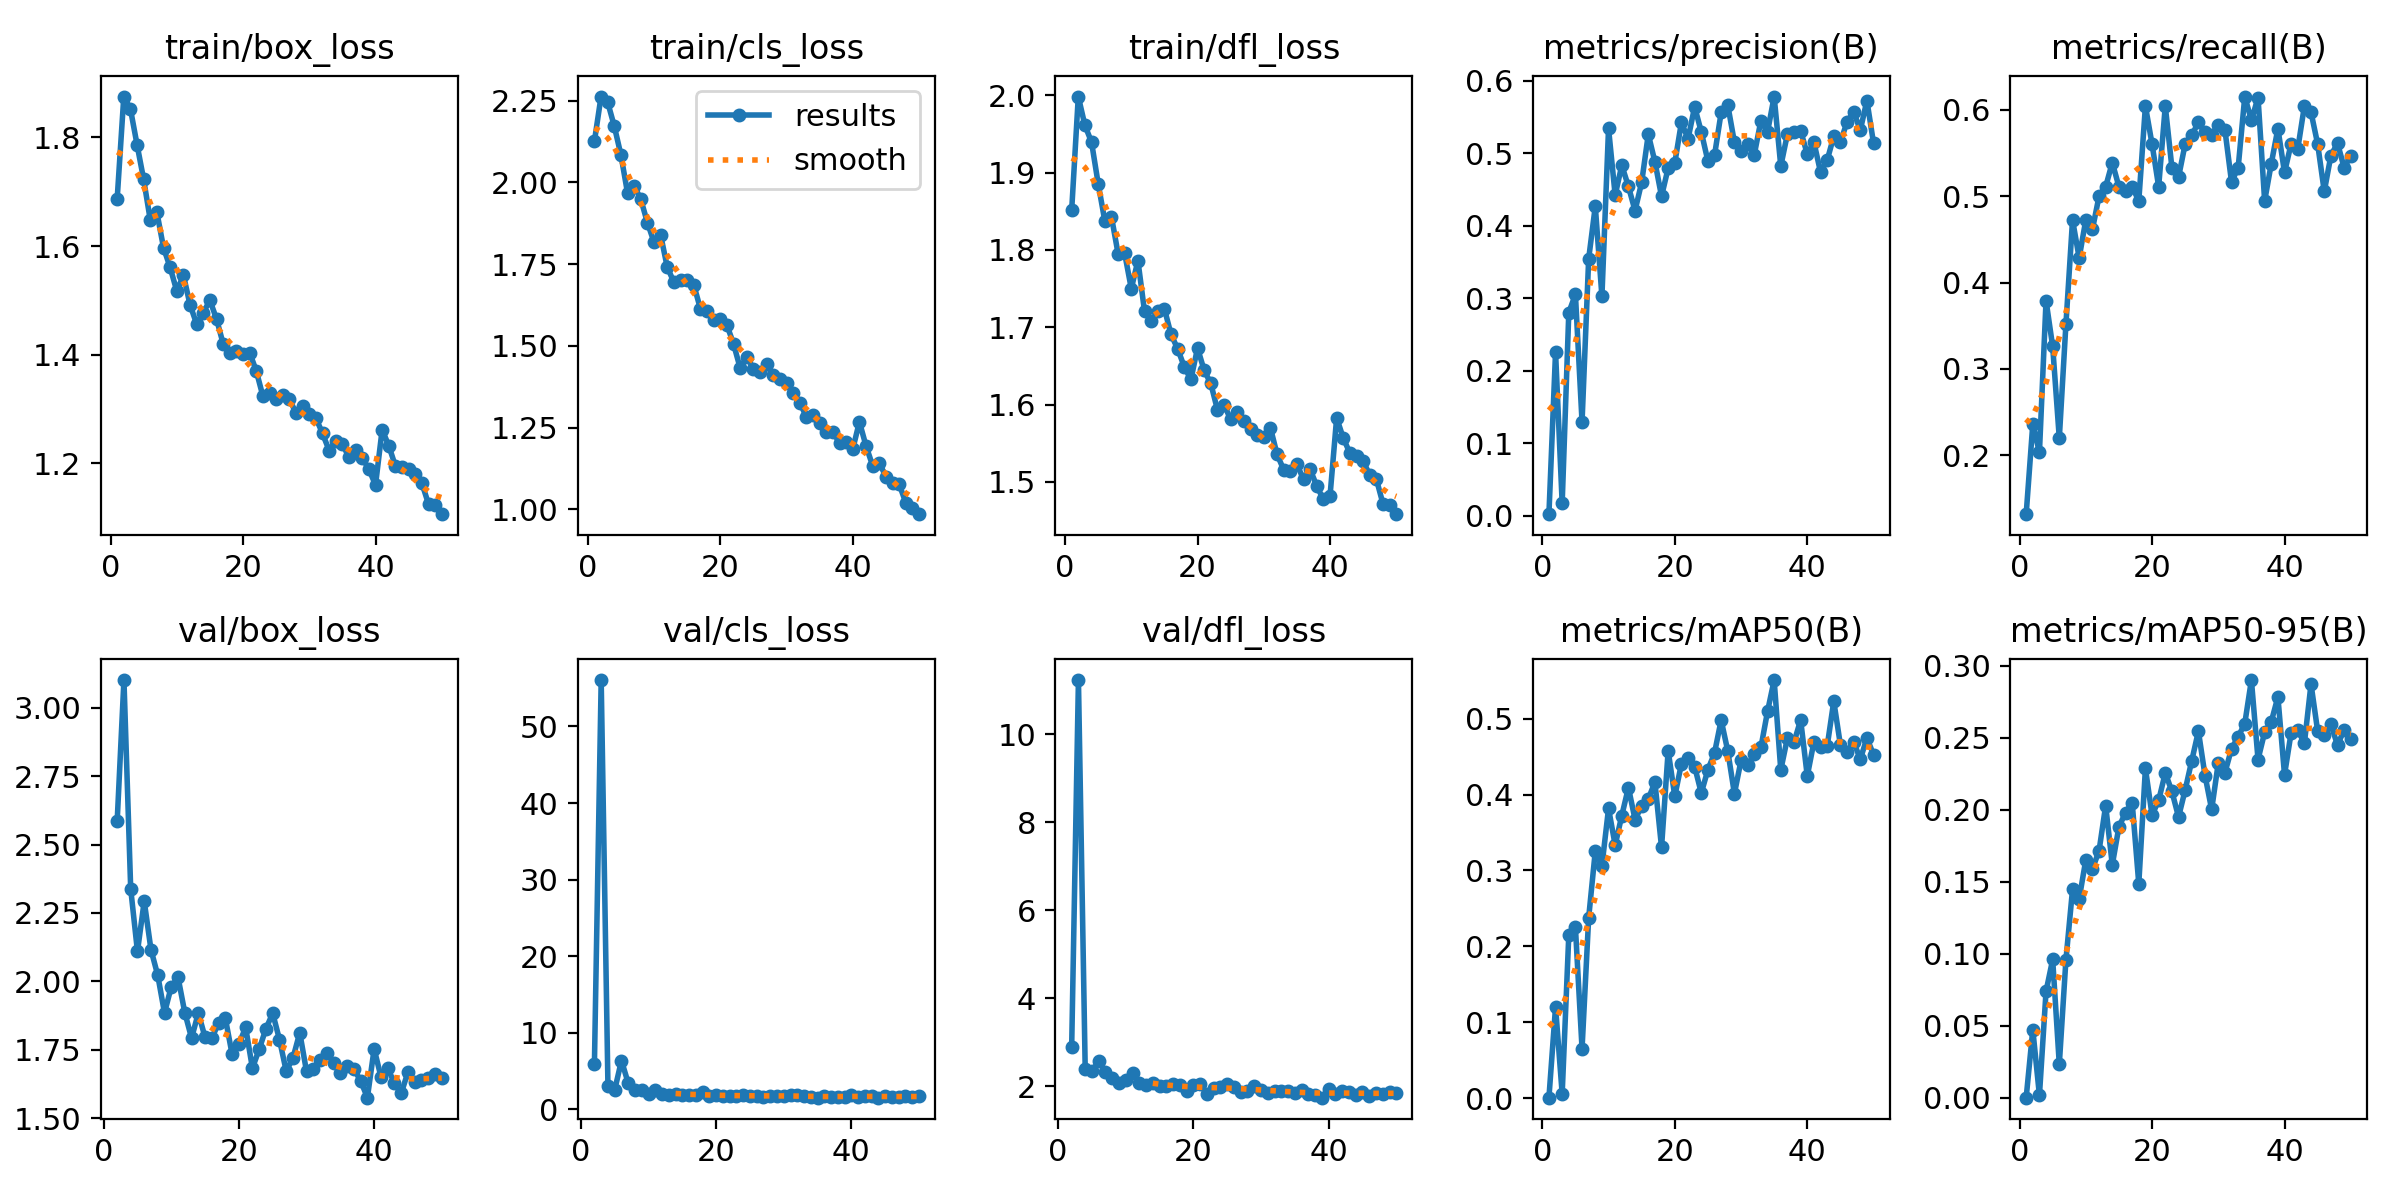


Confusion Matrix:


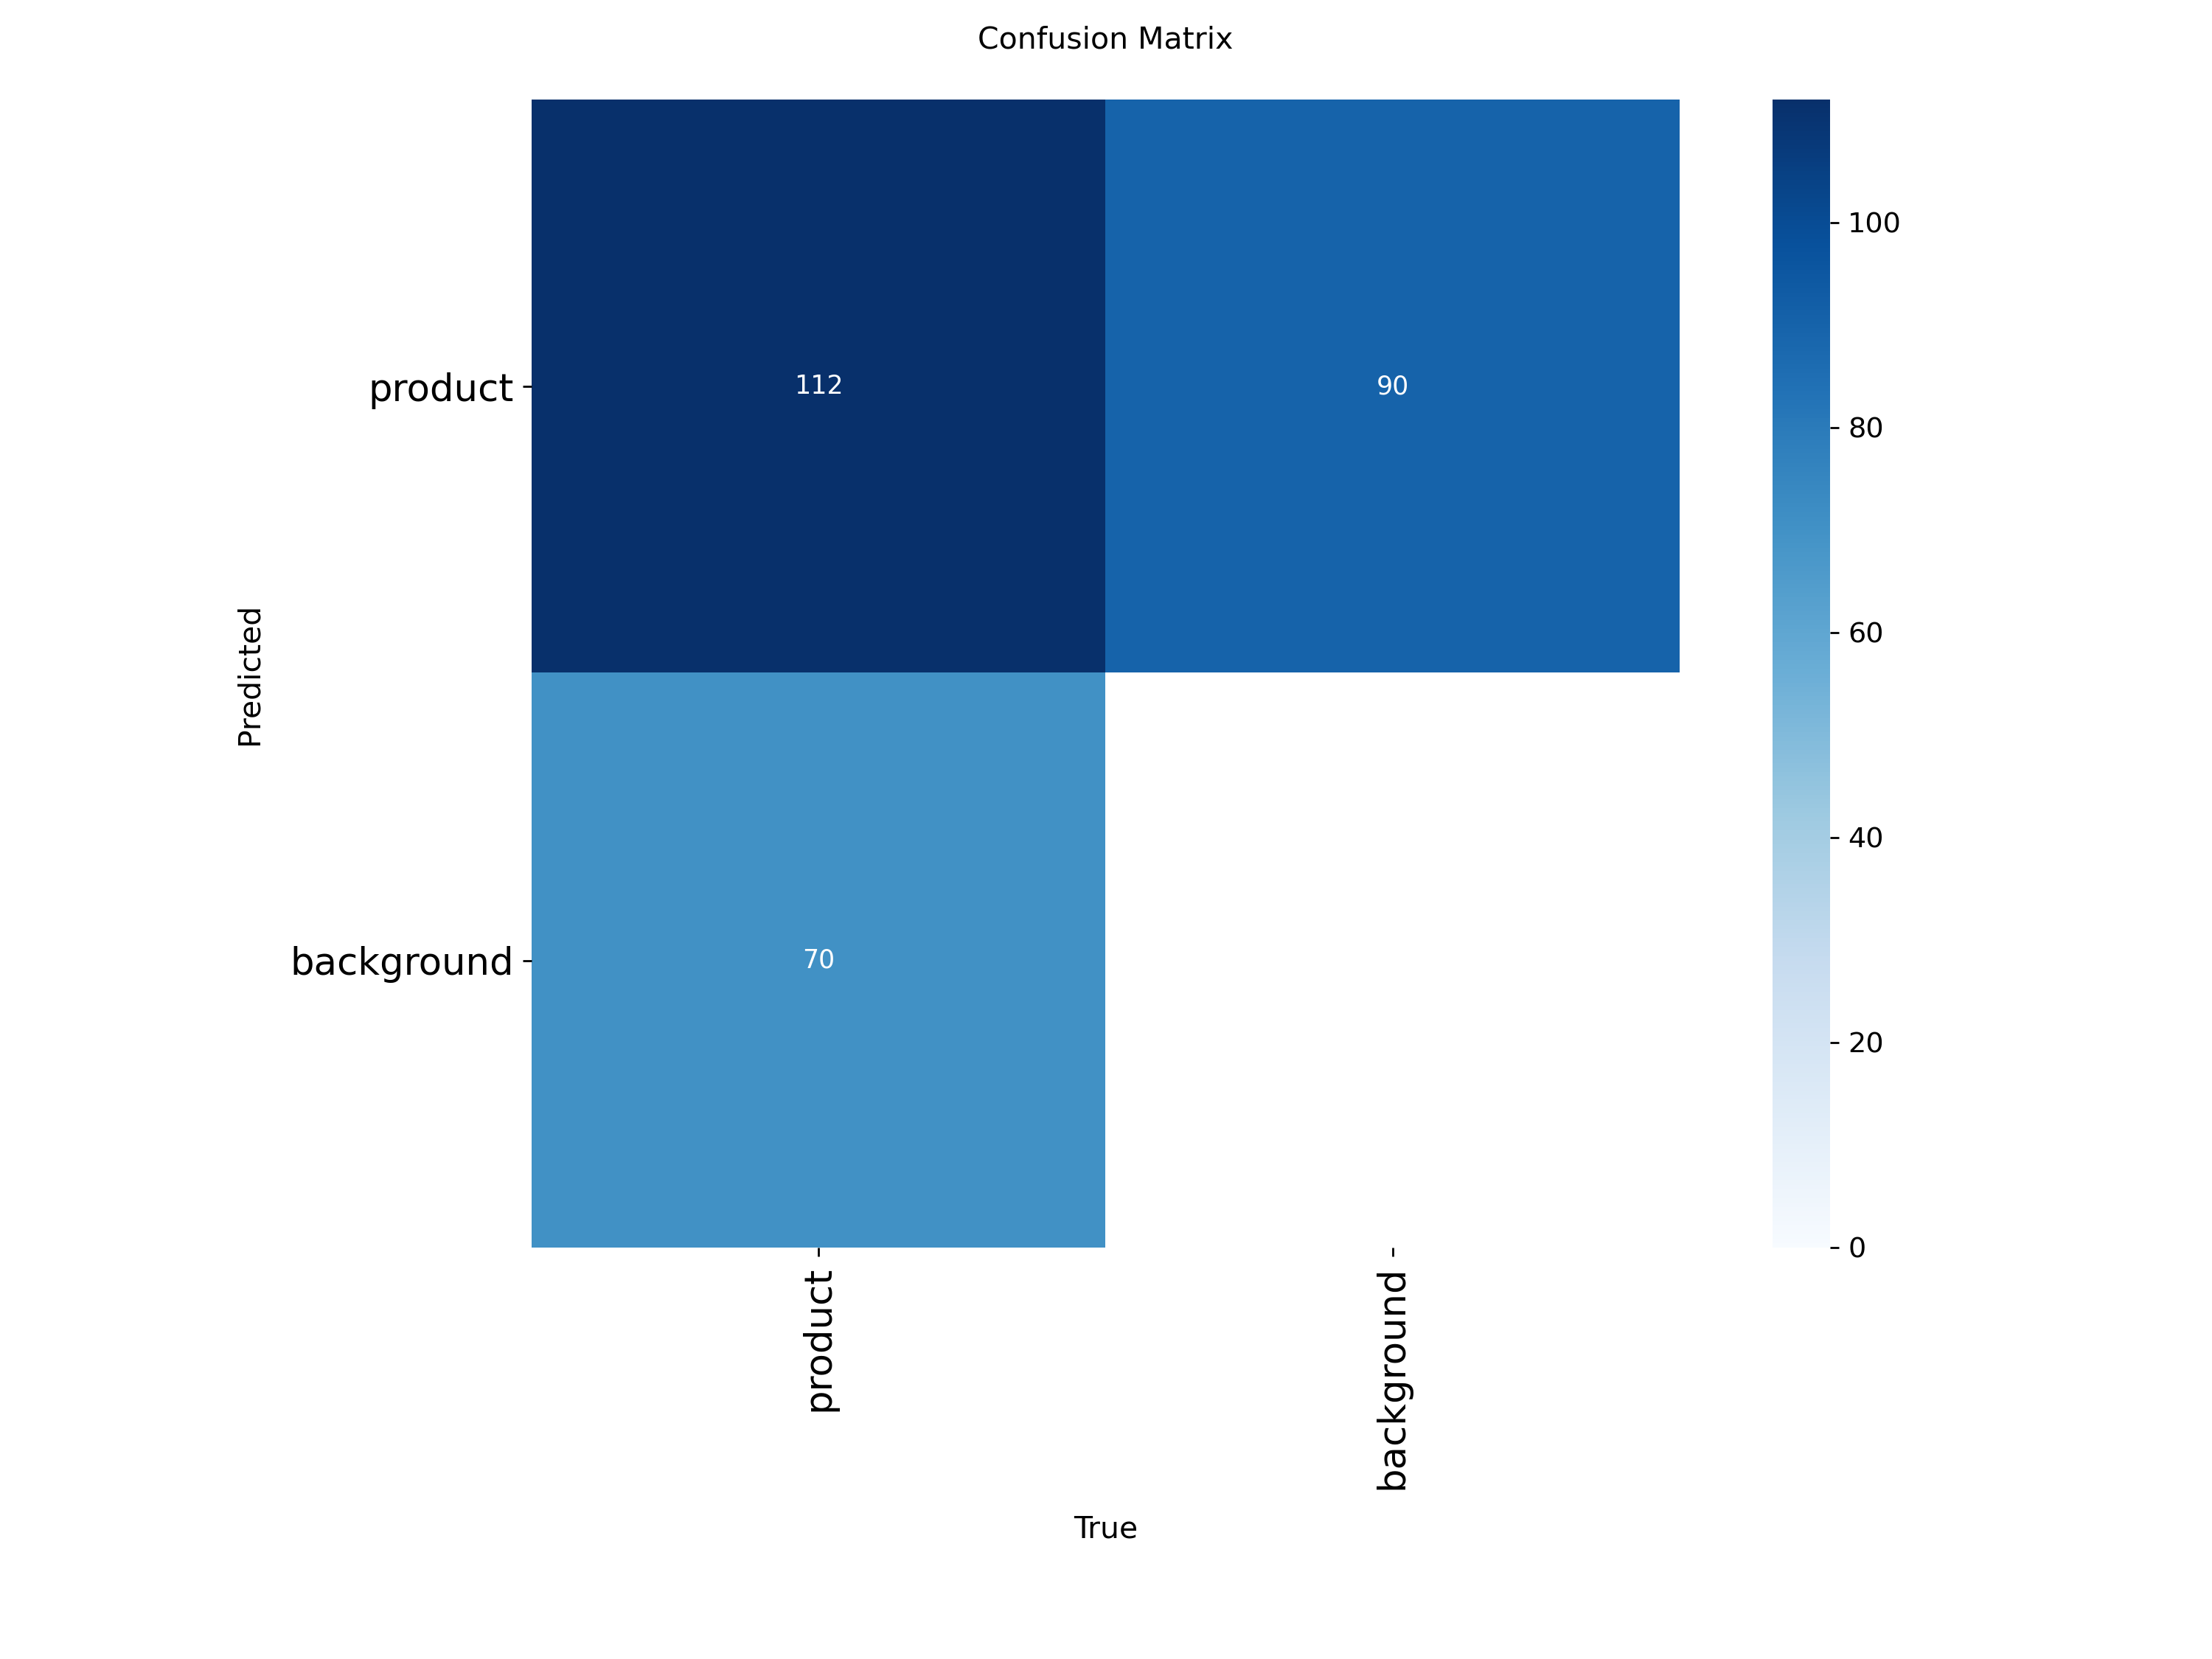


Metric Curves:


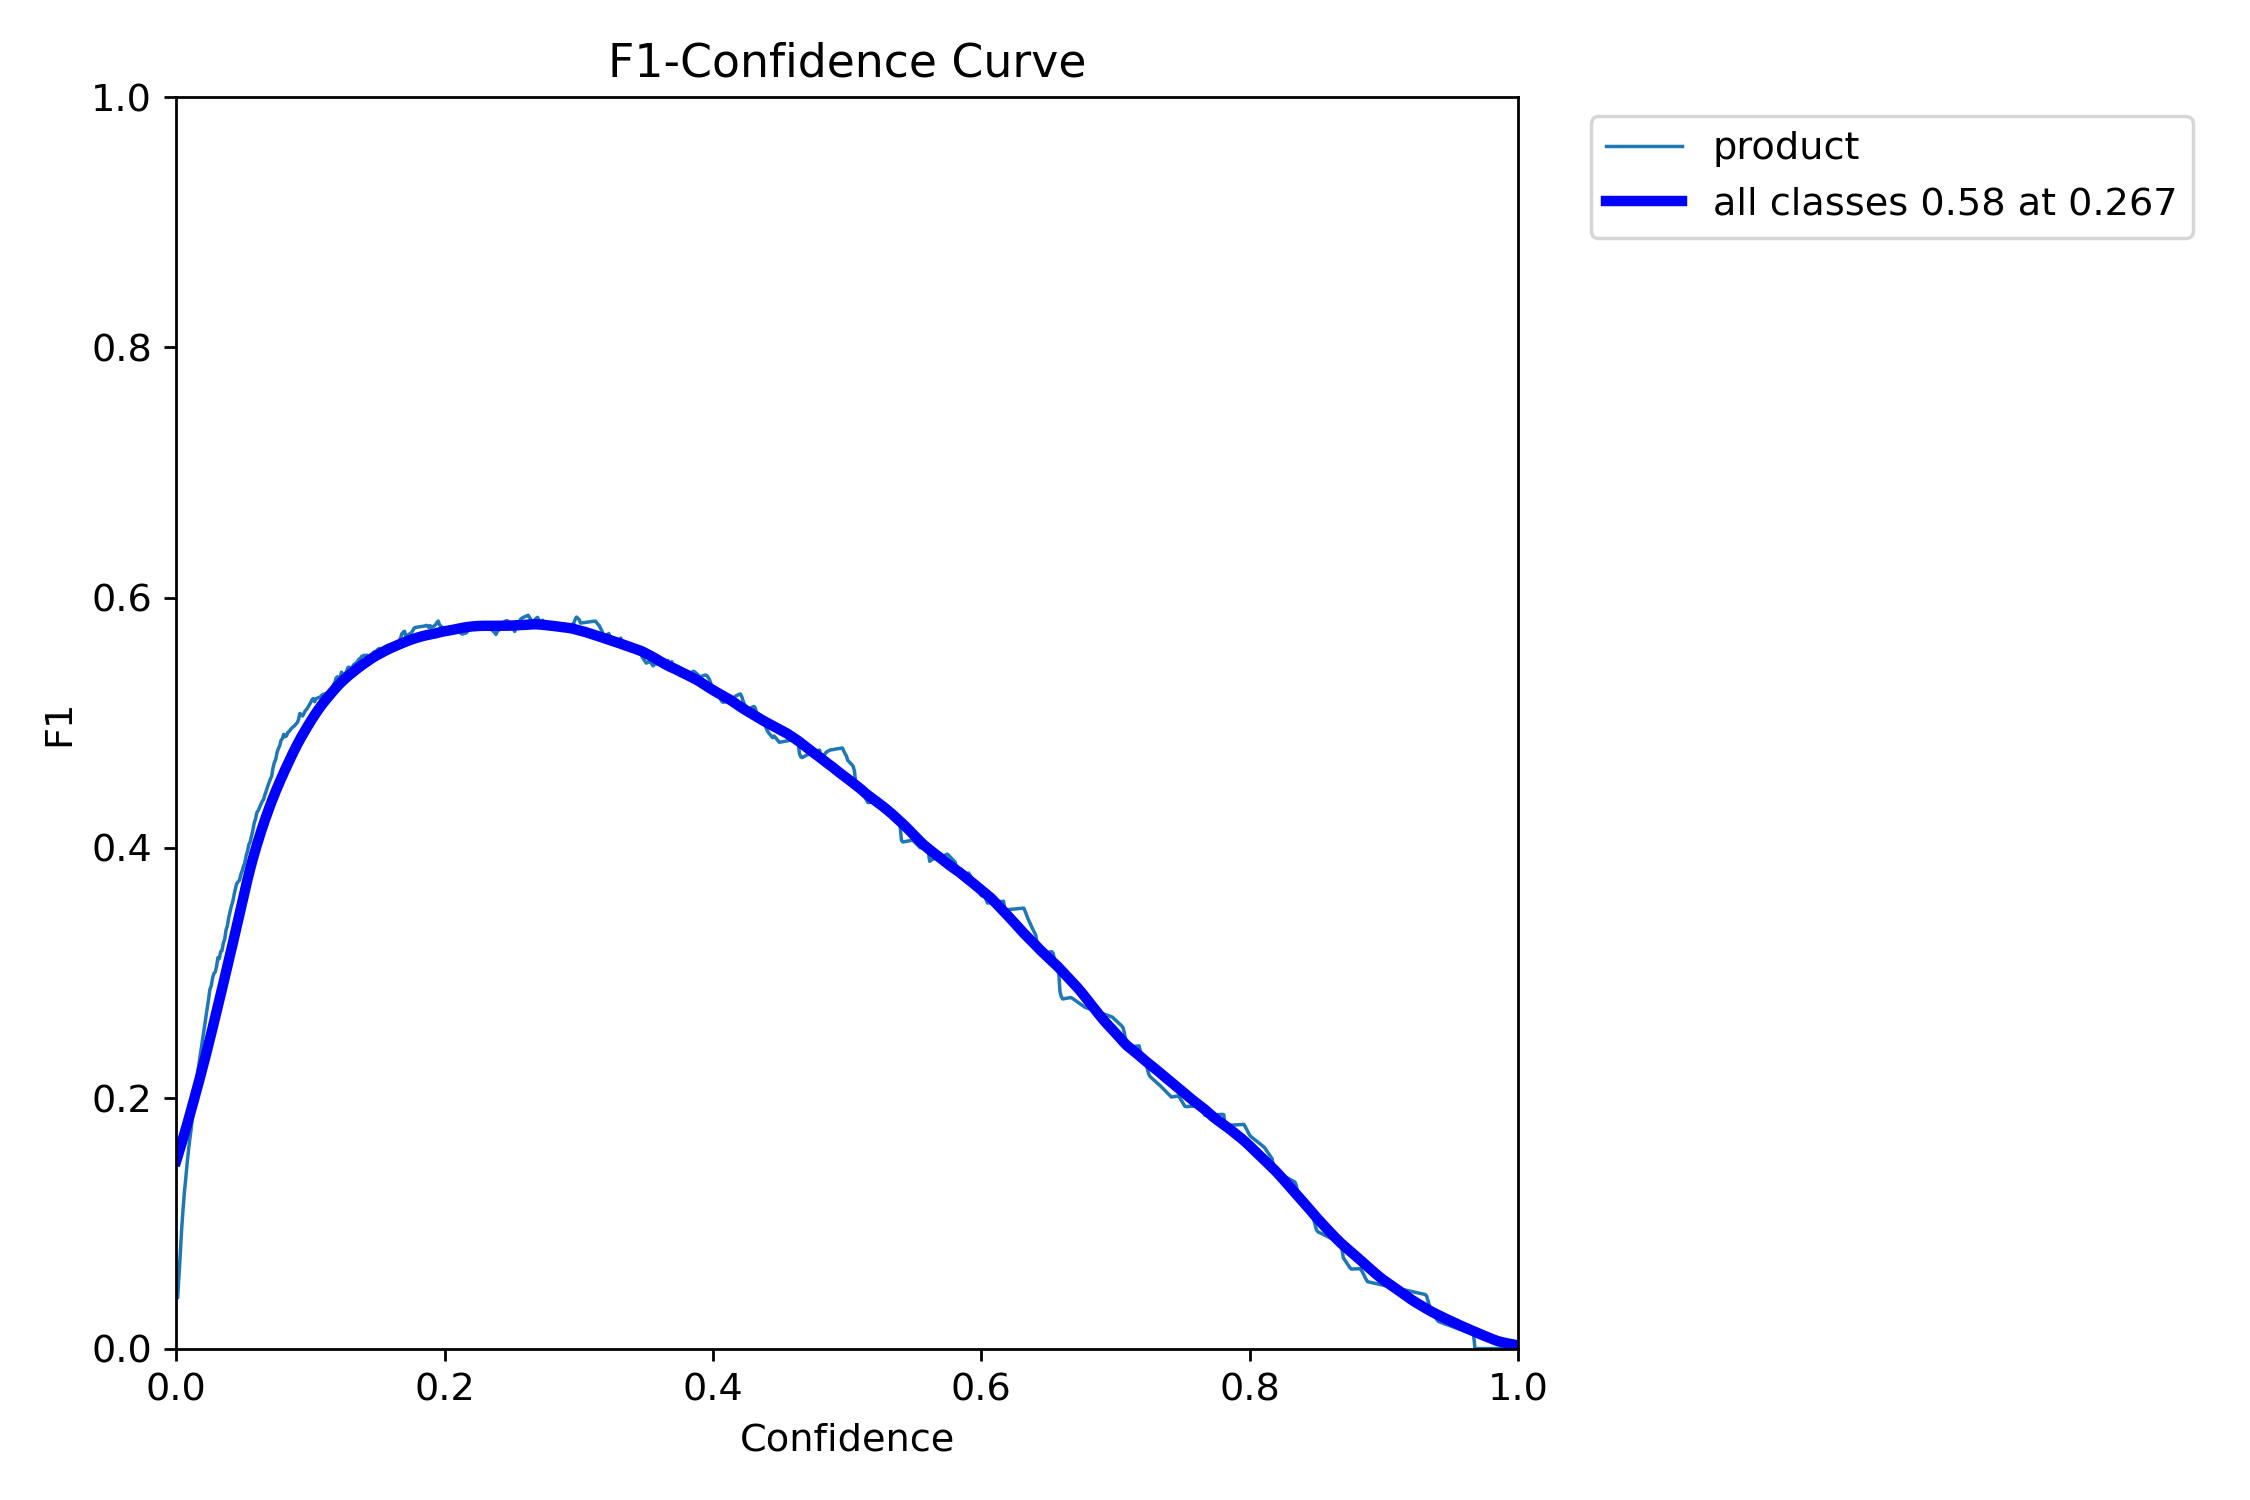

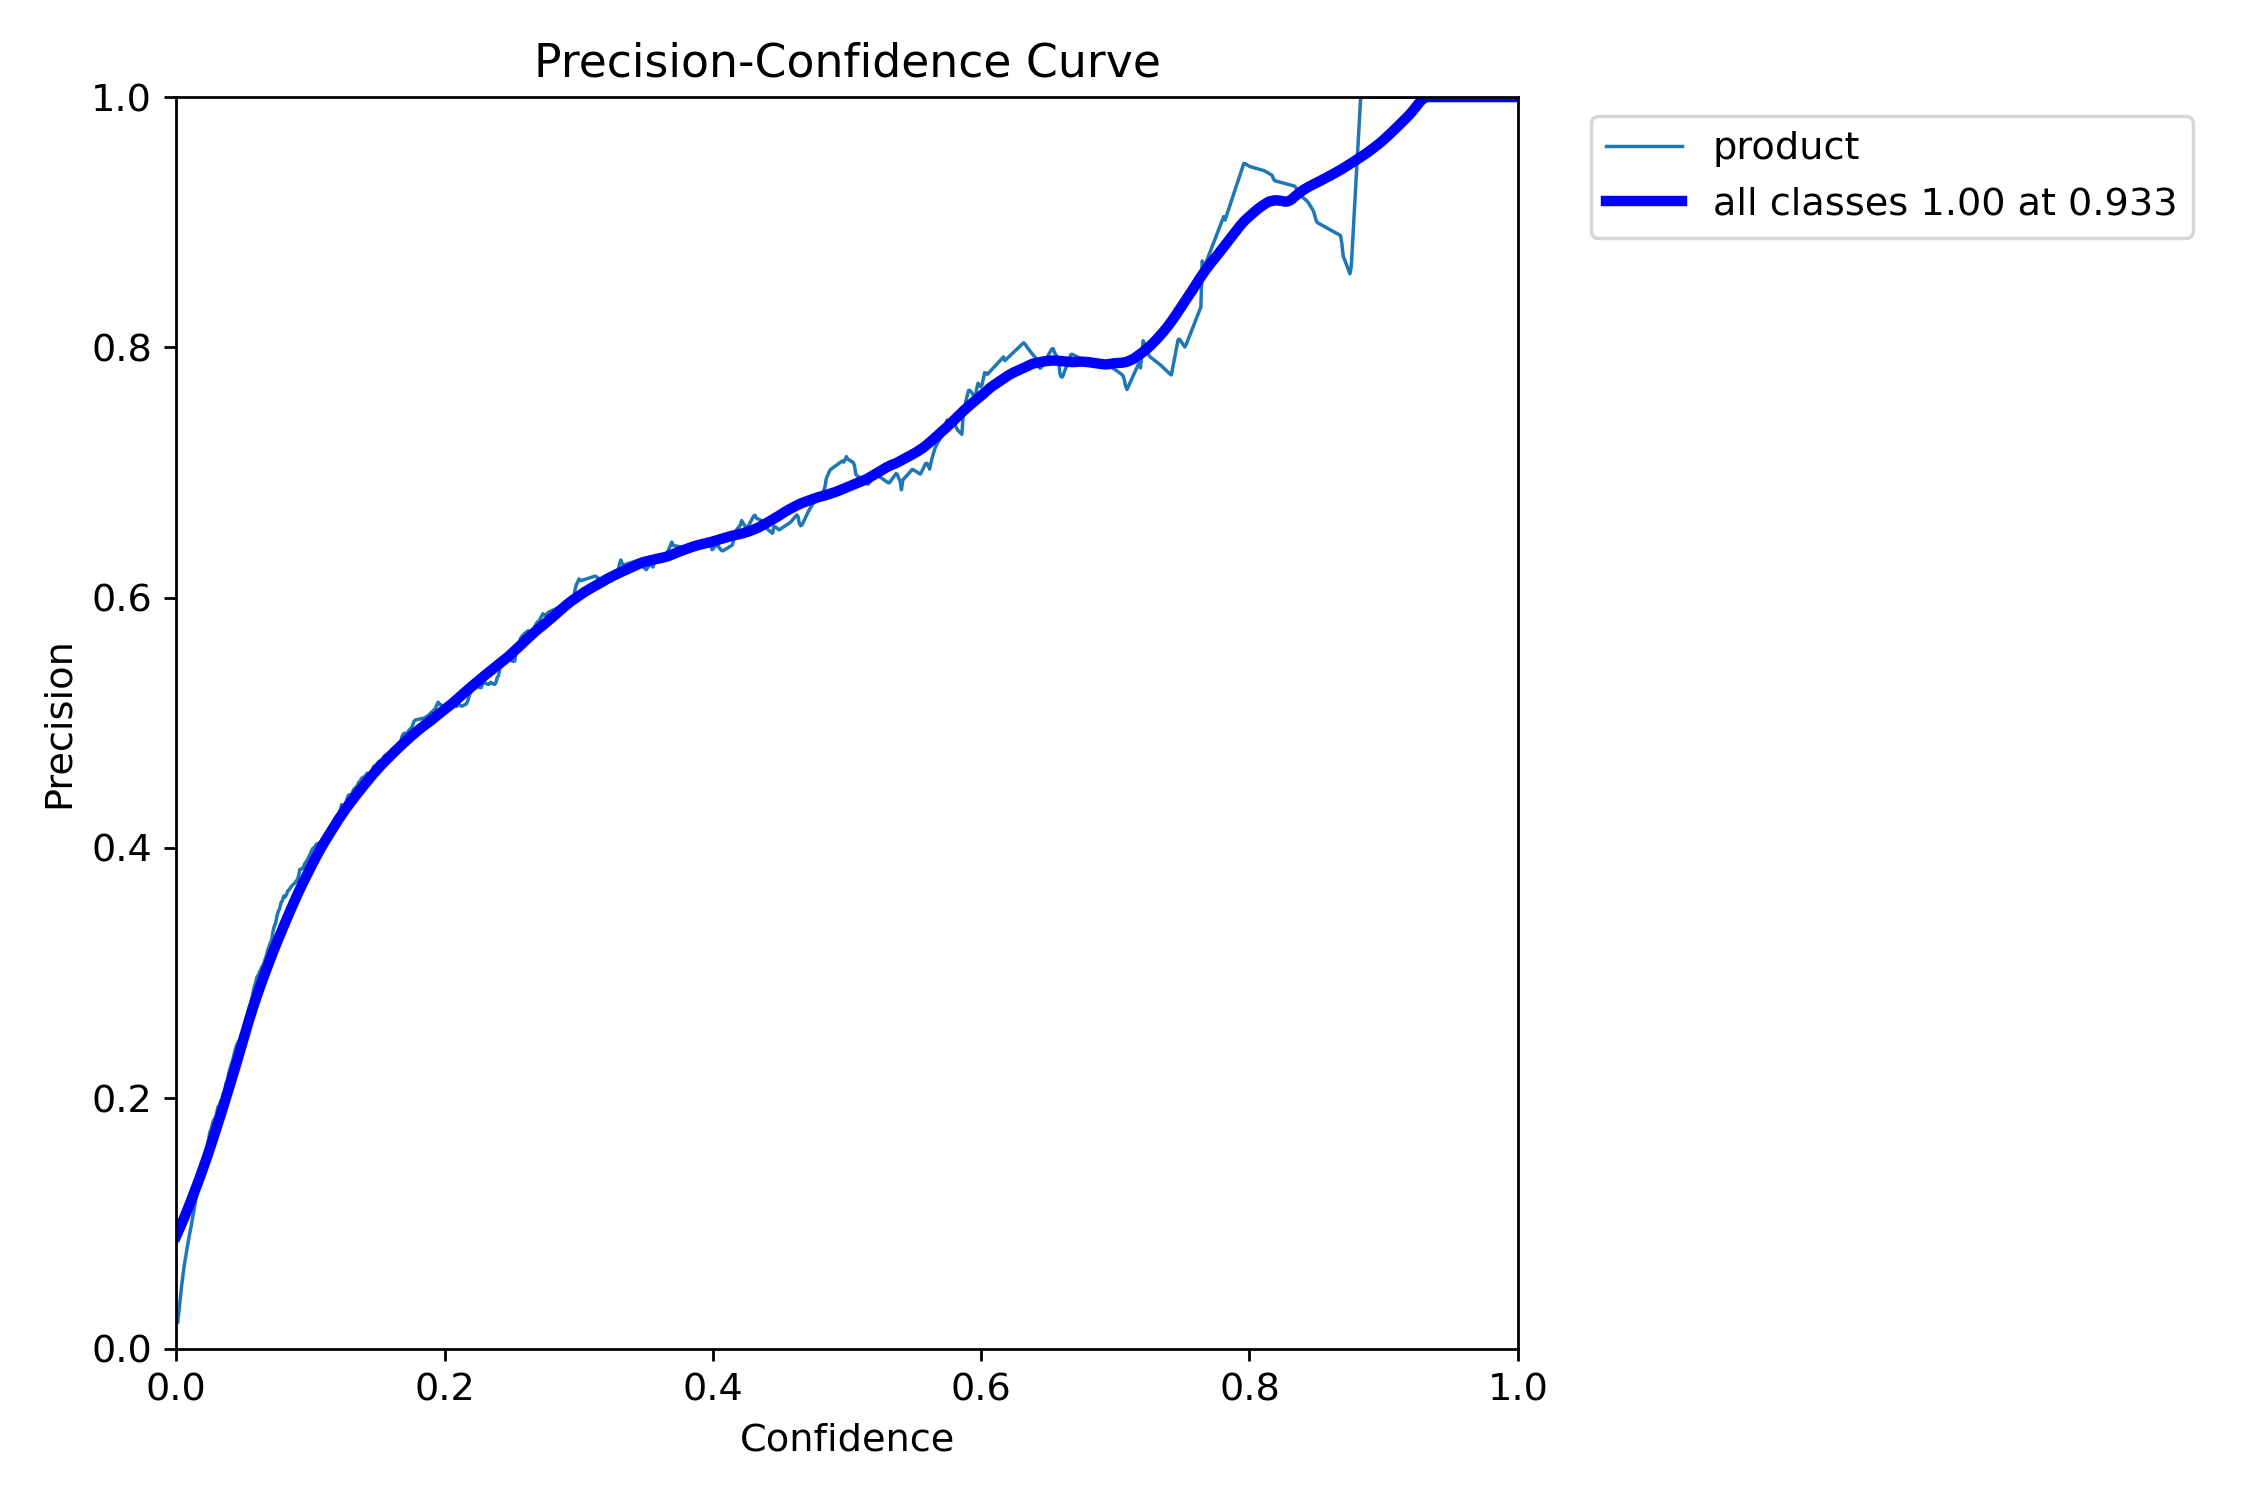

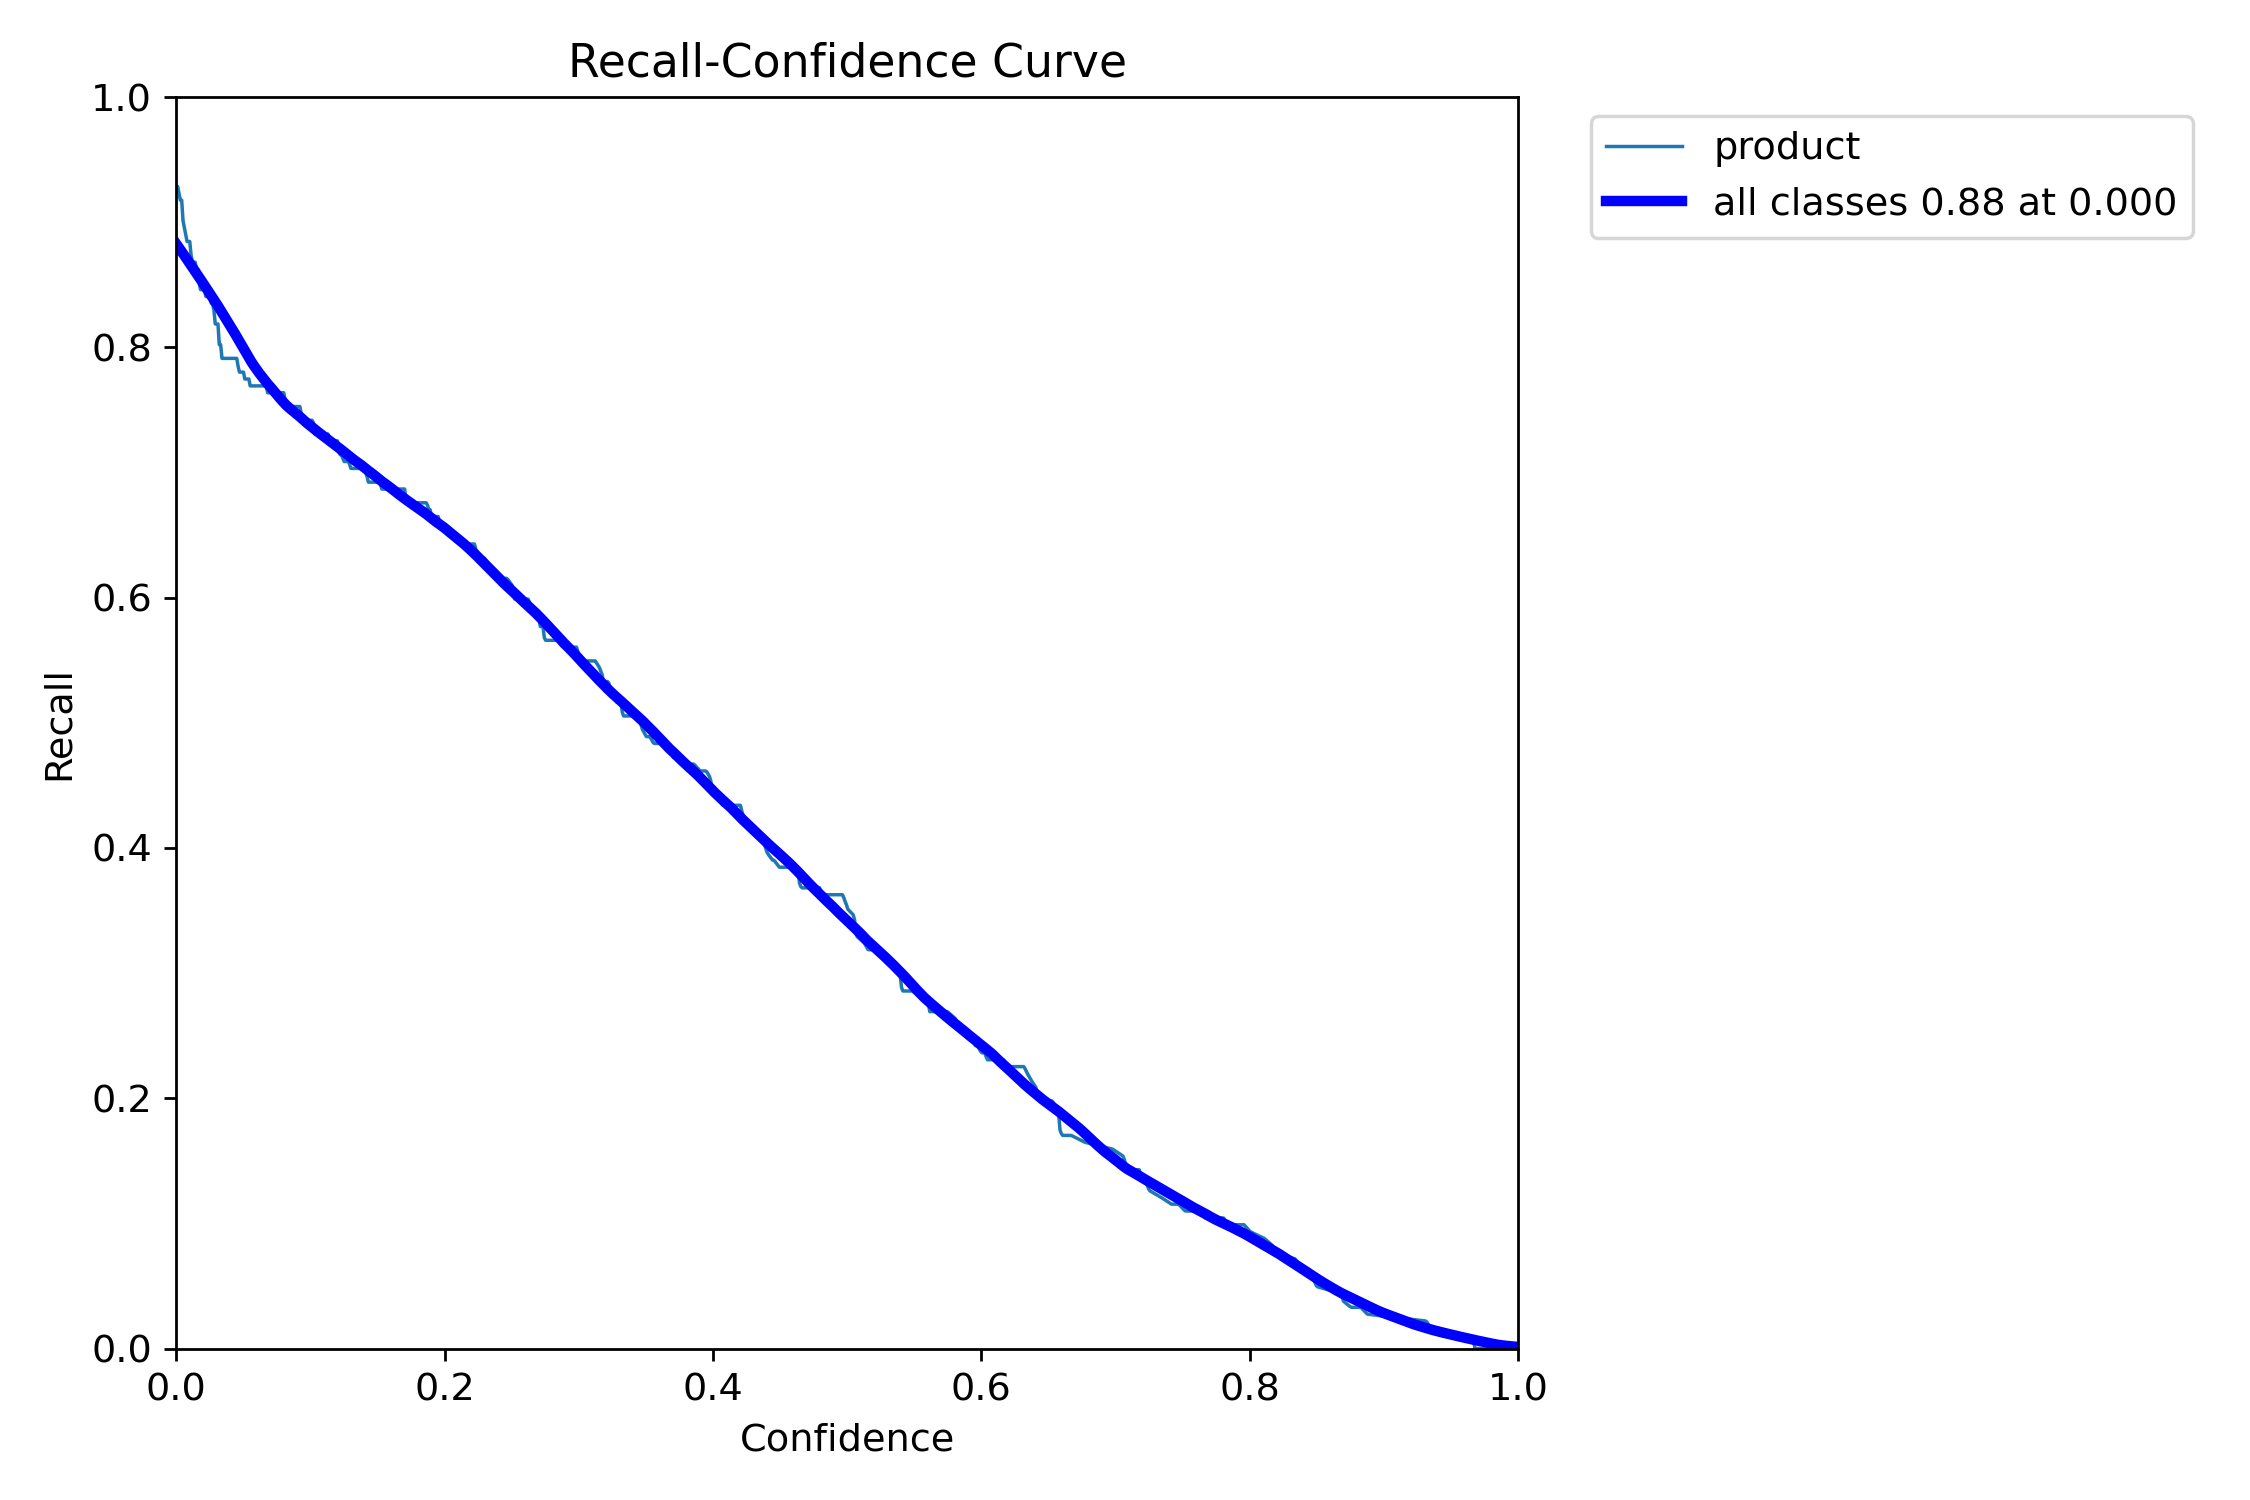

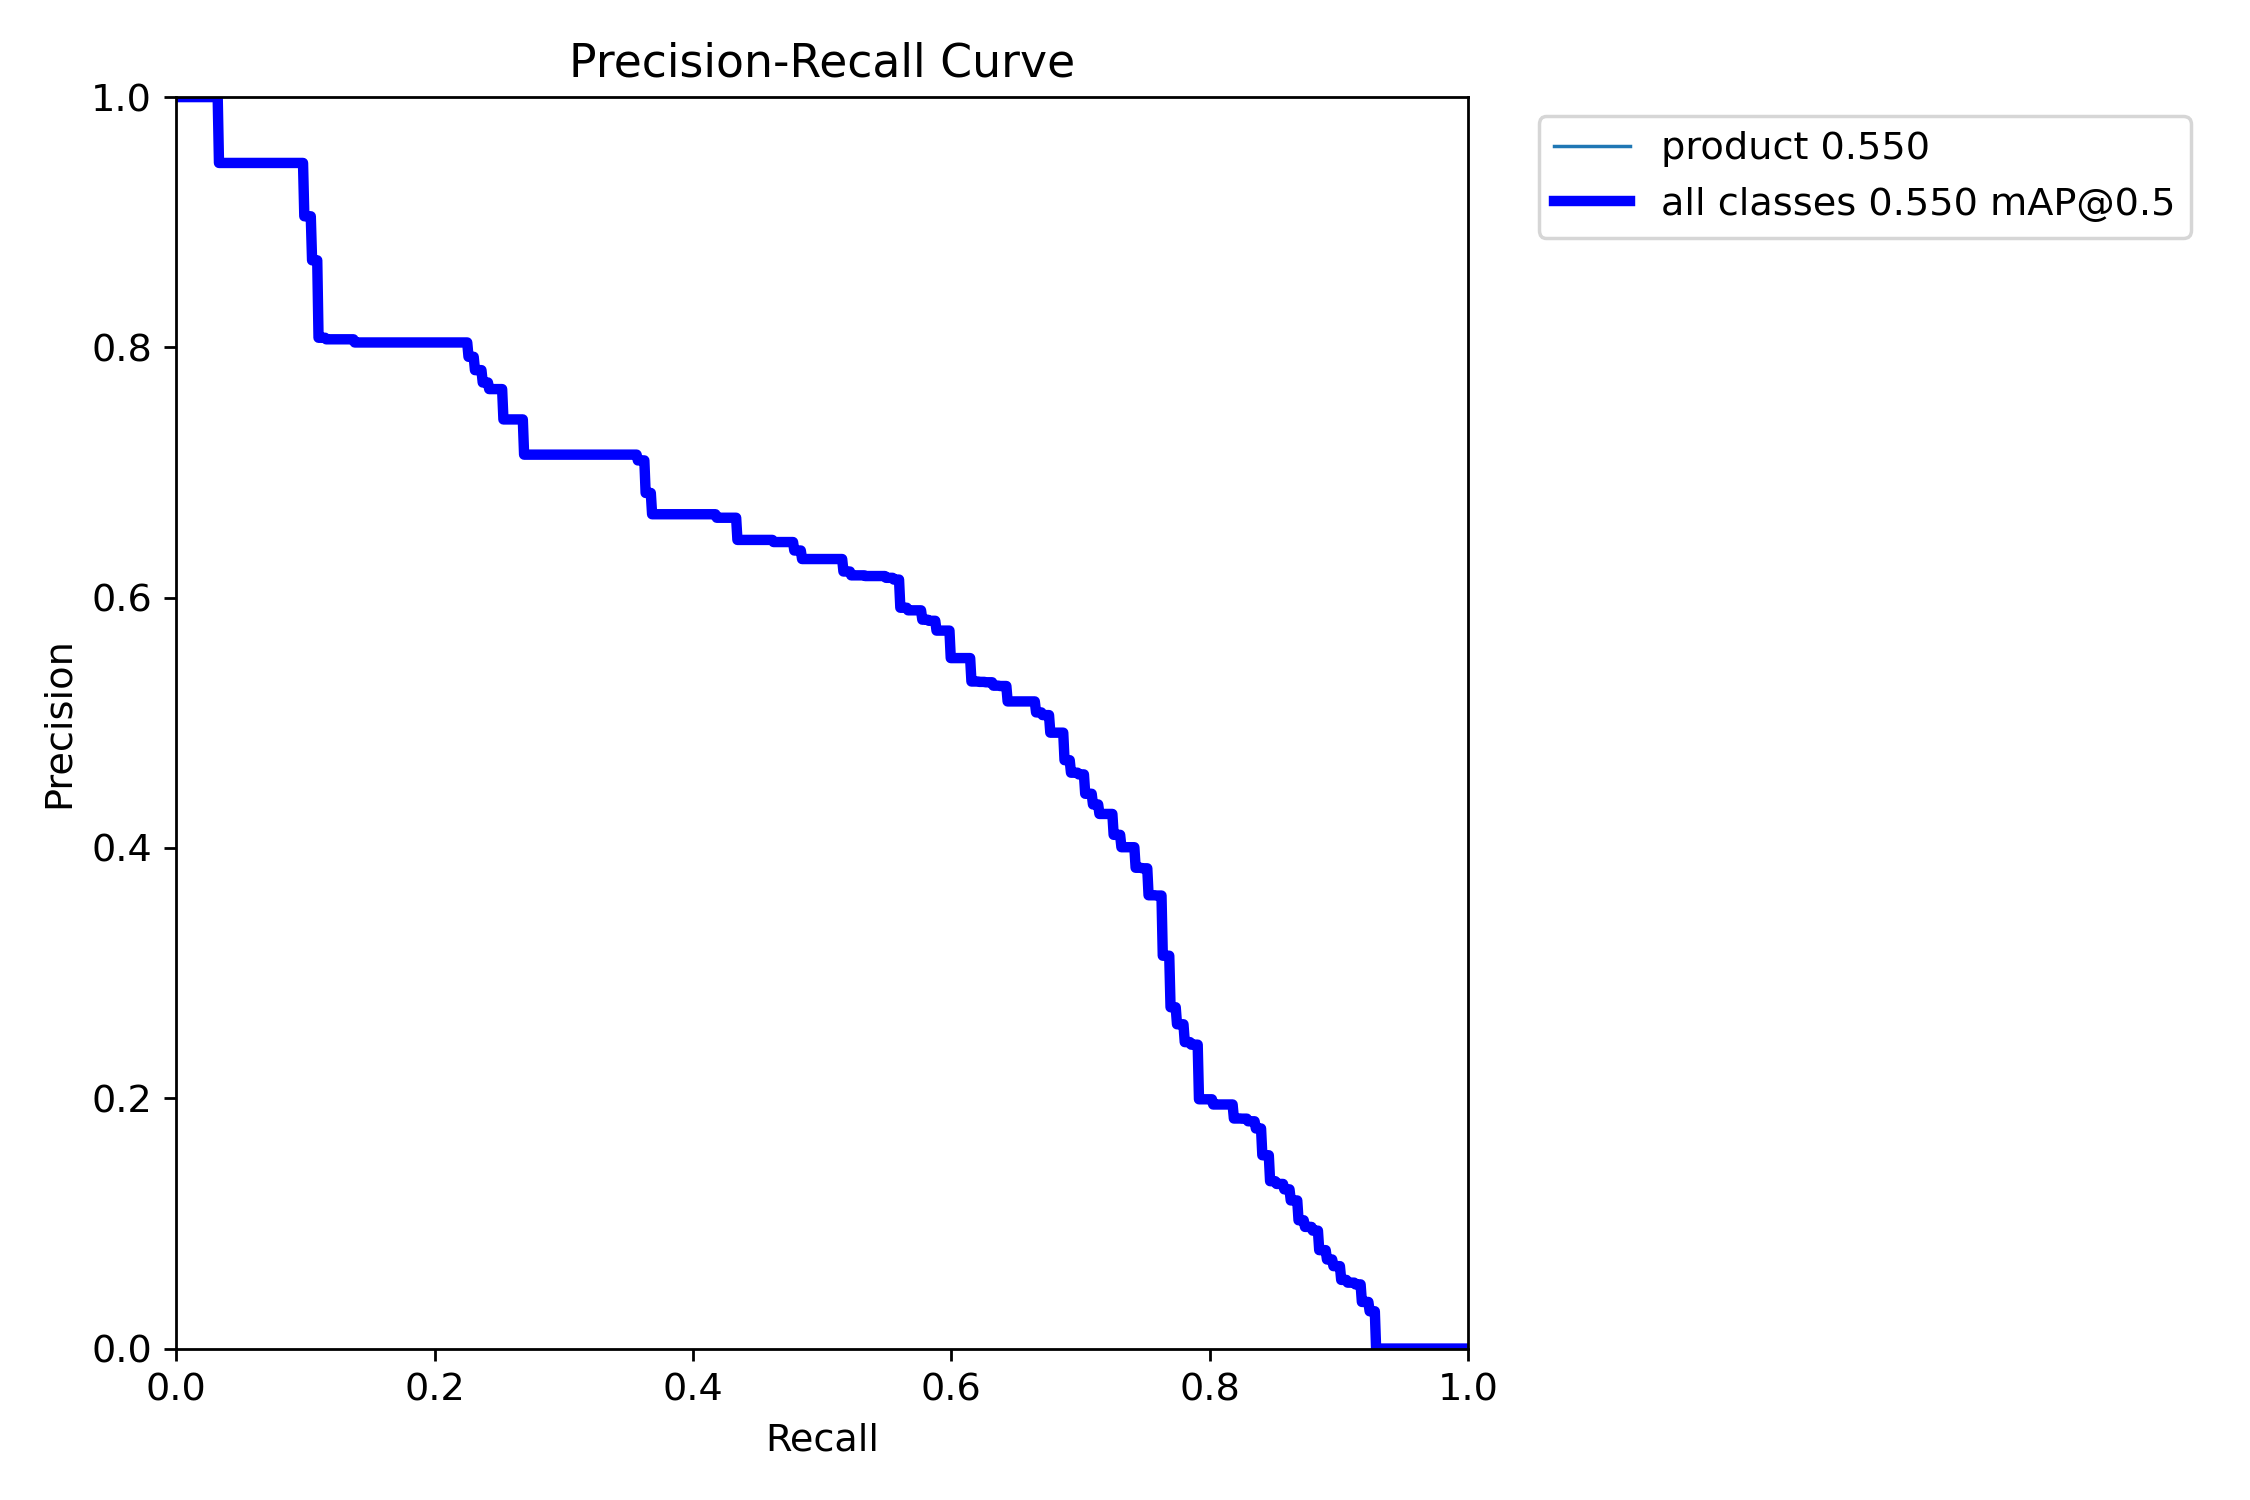

In [7]:
import glob
from IPython.display import Image, display

# Display training results (loss and mAP over epochs)
print("Training Results (Loss and Accuracy):")
results_img = glob.glob('/content/SupplyChain_YOLO/indian_market_model/results.png')
if results_img:
    display(Image(filename=results_img[0]))

# Display the confusion matrix
print("\nConfusion Matrix:")
conf_matrix = glob.glob('/content/SupplyChain_YOLO/indian_market_model/confusion_matrix.png')
if conf_matrix:
    display(Image(filename=conf_matrix[0]))

# Display other metric curves (F1, Precision, Recall)
print("\nMetric Curves:")
curves = glob.glob('/content/SupplyChain_YOLO/indian_market_model/*_curve.png')
for curve in curves:
    display(Image(filename=curve))

## STEP 6: Validate/Test Model Metrics
Run validation to compute the exact accuracy, precision, and recall metrics on the validation dataset.

In [8]:
# Run validation to get quantitative metrics
print("Running model validation...")
metrics = model.val()

print(f"\nMean Average Precision (mAP50-95): {metrics.box.map:.4f}")
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.4f}")

Running model validation...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 68,124,531 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1671.6±288.5 MB/s, size: 53.1 KB)
val: Scanning /content/dataset_small/valid/labels.cache... 41 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 41/41 11.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 27, len(boxes) = 182. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.5s
                   all         41        182      0.581      0.588      0.552      0.291
Speed: 7.0ms preprocess, 87.0ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /

## STEP 7: Run Inference (Visual Test)
Test your powerful model visually on new test images.


image 1/36 /content/dataset_small/test/images/1695021835765_jpg.rf.7cbfc64d3f7f126dcbf56503c45207bd.jpg: 640x640 3 products, 81.7ms
image 2/36 /content/dataset_small/test/images/20230702_135219_mp4-240_jpg.rf.462608a3c5b759bd62d3daac6e588228.jpg: 640x640 14 products, 69.9ms
image 3/36 /content/dataset_small/test/images/20230702_135350_mp4-85_jpg.rf.78b523ea1646f7806e69e2e66e18c375.jpg: 640x640 10 products, 74.0ms
image 4/36 /content/dataset_small/test/images/20230702_140138_mp4-8_jpg.rf.2c2e29efae6d59c90f489353bdce9750.jpg: 640x640 5 products, 76.7ms
image 5/36 /content/dataset_small/test/images/20230812_083711_jpg.rf.9b9495f14d59f275121d157bf1a42033.jpg: 640x640 6 products, 67.7ms
image 6/36 /content/dataset_small/test/images/20230812_083830_jpg.rf.cd15140c81ab7e8fb89fd3d489add7fa.jpg: 640x640 5 products, 71.8ms
image 7/36 /content/dataset_small/test/images/2fb1aecb-7b0d-469c-a11a-bc00cb7cdd3a_jpg.rf.dd6aec8b2e7eb24dac828e7e803e996d.jpg: 640x640 2 products, 70.5ms
image 8/36 /content

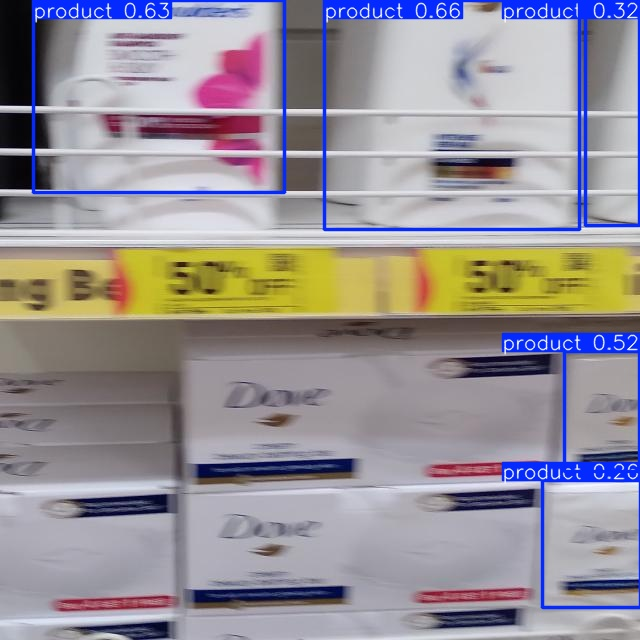

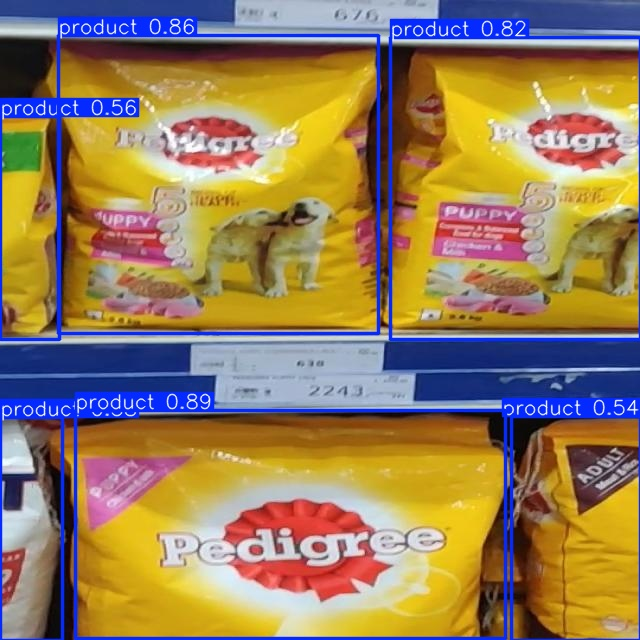

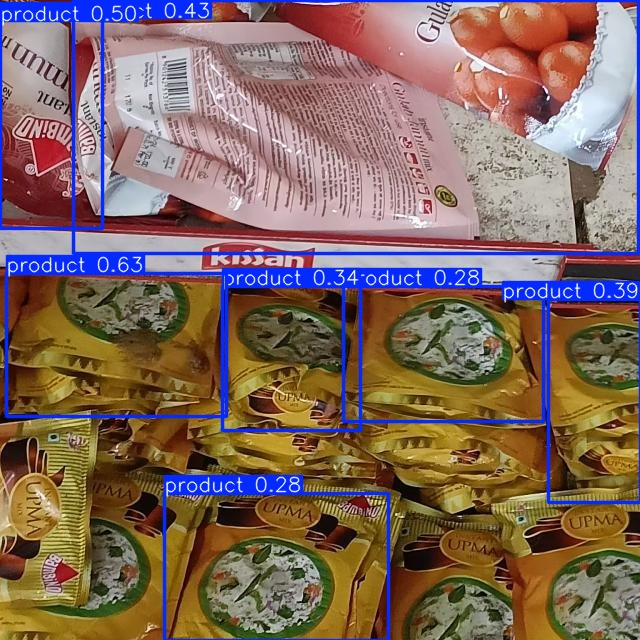

In [9]:
# Path to test images (fallback to valid/images if no test set was split out)
test_images = os.path.join(DATASET_DIR, 'test/images')
if not os.path.exists(test_images):
    test_images = os.path.join(DATASET_DIR, 'valid/images')

# Detect on test images
results = model.predict(source=test_images, save=True, project='/content', name='runs/detect/predict')

# Display a couple output images with bounding boxes
predicted_images = glob.glob('/content/runs/detect/predict/*.jpg')
for img in predicted_images[:3]:
    display(Image(filename=img))

In [11]:
print("--- Product Counts for Displayed Images ---")
for r in results[:3]:
    img_name = os.path.basename(r.path)
    count = len(r.boxes)
    print(f"Image [{img_name}] contains {count} product(s)!")


--- Product Counts for Displayed Images ---
Image [1695021835765_jpg.rf.7cbfc64d3f7f126dcbf56503c45207bd.jpg] contains 3 product(s)!
Image [20230702_135219_mp4-240_jpg.rf.462608a3c5b759bd62d3daac6e588228.jpg] contains 14 product(s)!
Image [20230702_135350_mp4-85_jpg.rf.78b523ea1646f7806e69e2e66e18c375.jpg] contains 10 product(s)!


## STEP 8: Save and Export the Model
Your model is saved locally in Colab. You can find the best weights at `/content/SupplyChain_YOLO/indian_market_model/weights/best.pt`.

Below, we will also export the model to ONNX format, which is widely used for deployment in production applications and can be downloaded.

In [10]:
import shutil

# Path to the best trained model
best_model_path = '/content/SupplyChain_YOLO/indian_market_model/weights/best.pt'
print(f"Best model is saved at: {best_model_path}")

# Export the model to ONNX format
try:
    onnx_path = model.export(format='onnx')
    print(f"\nModel exported successfully to ONNX format at: {onnx_path}")
except Exception as e:
    print(f"\nError exporting model: {e}")

from google.colab import files
# Automatically download the best model to your PC
print("\nInitiating download of the best model to your PC. Please check your Downloads folder...")
files.download(best_model_path)

# Make sure to download the ONNX model to your PC if exported successfully
if 'onnx_path' in locals():
    print("Initiating download of the ONNX model to your PC...")
    files.download(onnx_path)


Best model is saved at: /content/SupplyChain_YOLO/indian_market_model/weights/best.pt
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/SupplyChain_YOLO/indian_market_model/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (130.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 212ms
Prepared 4 packages in 9.70s
Installed 4 packages in 350ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 10.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Initiating download of the ONNX model to your PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>